# Does the judge's prompt language change the answer?

Every result in this pilot is produced by an LLM judge. The judge reads the model's response, decides whether it was an answer or a refusal, picks a refusal code, and scores answer quality from 1 to 5. Until now that judge has always been instructed in English, even when the response it is reading is in Russian or Cantonese.

That is a threat to the main finding. [`pilot_v2_eval_exploration.ipynb`](pilot_v2_eval_exploration.ipynb) reports that translation makes the model refuse answerable questions it would have answered in English. If an English-instructed judge is simply harsher, or noisier, on text it was not instructed in, that pattern would appear even if the model behaved identically in all five languages. The finding would then be a property of the measuring instrument rather than of the model.

**The test.** `judge_bedrock.py` takes a `--judge-prompt-language` flag. The default, `english`, sends the canonical English instruction block whatever the response language. Setting it to `target` swaps in translated judge segments, so a Russian response is judged by a judge that was itself instructed in Russian. Both runs now exist over the same 900 inference records.

| run | directory | judge instructions |
|---|---|---|
| canonical | `data/pilot_v2_eval` | English for all five languages |
| localised | `data/pilot_v2_eval_localised` | each language in its own language |

**What makes this readable is a built-in placebo.** For English the localised prompt *is* the canonical prompt, because translating English into English changes nothing. So the 180 English items were re-judged with an identical instrument. Whatever moves in the English slice cannot be an effect of localisation. It can only be the judges being non-deterministic, giving slightly different verdicts on a re-run of the same work. That gives a floor. A change in a non-English language means something only if it is larger than the change English shows, and section 1 measures that floor before any result is looked at.

**This is not the leakage question.** [`pilot_v2_leakage_subsets.ipynb`](pilot_v2_leakage_subsets.ipynb) asks whether the *model's input* was contaminated with English. This notebook asks whether the *measurement* was. They are independent threats to the same claim and neither answers the other, which is why they are separate notebooks. Conclusion 8 of that notebook is the request this one answers.

In [ ]:
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from refusalbench.multilingual.aggregate import ANSWER_CORRECTLY, VALID_REFUSAL_CODES

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.width", 200)

REPO = Path.cwd()

if not (REPO / "data" / "pilot_v2_eval").is_dir():
    REPO = REPO.parent

CANON = REPO / "data" / "pilot_v2_eval"
LOCAL = REPO / "data" / "pilot_v2_eval_localised"

LANGS = ["en", "pl", "ru", "zh_cmn", "zh_yue"]
OTHER = ["pl", "ru", "zh_cmn", "zh_yue"]
JUDGES = ["mistral-large-3", "nemotron-3-super", "sonnet4_5"]
REFUSAL_CODES = set(VALID_REFUSAL_CODES)

# the two runs are the same instrument pointed at the same records, so they are
# named after the instrument rather than after the directory.
RUNS = {"english prompt": CANON, "target prompt": LOCAL}


def load_consensus(path):
    """consensus rows with the derived outcome columns the metrics are built from."""
    frame = pd.read_csv(path / "consensus.csv")
    frame["answerable"] = frame["ground_truth_label"].eq(ANSWER_CORRECTLY)
    frame["refused"] = frame["model_predicted_type"].astype(str).isin(REFUSAL_CODES)
    frame["correct"] = (frame["model_predicted_type"].eq("answer_attempt")
                        & (frame["answer_quality_score"] >= 4))
    frame["code_ok"] = frame["refusal_match_correct"] == True  # noqa: E712
    
    return frame


consensus = {name: load_consensus(path) for name, path in RUNS.items()}
merged = {name: pd.read_csv(path / "judgments_merged.csv").query("status == 'ok'")
          for name, path in RUNS.items()}
agreement = {name: pd.read_csv(path / "judge_agreement.csv") for name, path in RUNS.items()}
metrics_lang = {name: pd.read_csv(path / "metrics_by_language.csv") for name, path in RUNS.items()}

# a paired comparison between runs is only meaningful on identical coverage, so
# refuse to continue if the two runs do not describe exactly the same records.
key = ["id", "language"]
assert (set(map(tuple, consensus["english prompt"][key].values))
        == set(map(tuple, consensus["target prompt"][key].values))), "consensus coverage differs"
assert len(merged["english prompt"]) == len(merged["target prompt"]), "judge row counts differ"

print("consensus rows per run:", {k: len(v) for k, v in consensus.items()})
print("per-judge ok rows per run:", {k: len(v) for k, v in merged.items()})
print("judge call failures:", {k: len(pd.read_csv(p / "failures.csv")) for k, p in RUNS.items()})

consensus rows per run: {'english prompt': 900, 'target prompt': 900}
per-judge ok rows per run: {'english prompt': 2700, 'target prompt': 2700}
judge call failures: {'english prompt': 0, 'target prompt': 0}


## 1. The placebo, and the noise floor it measures

The placebo argument rests on two claims, and both are checked here rather than assumed.

**First, that the English localised prompt really is the canonical prompt.** If the two differed even slightly, the English slice would be measuring localisation rather than noise and the whole floor argument would collapse. The cell below builds both prompts from the same functions the judging pipeline uses and compares them line by line.

**Second, that re-judging identical work still moves some verdicts.** LLM judges are not deterministic, so the same prompt on the same response can come back with a different answer. The cell measures how often that happens, per language, on two things separately: the classification label and the 1 to 5 quality score.

Each language contributes 540 rows here, which is 180 items seen by each of the three judges.

In [2]:
from refusalbench.multilingual.judge_bedrock import (
    build_judge_prompt,
    build_judge_prompt_localised,
    load_judge_prompt_segments,
)

segments = load_judge_prompt_segments(
    REPO / "data" / "pilot_v2" / "refusalbench_translation_shared_prompts.csv"
)
probe = ("QUERY", "MODEL OUTPUT", "REFERENCE")
canonical_prompt = build_judge_prompt(*probe)
english_localised = build_judge_prompt_localised(segments["en"], *probe)

identical = canonical_prompt == english_localised
stripped_equal = ([line.rstrip() for line in canonical_prompt.splitlines()]
                  == [line.rstrip() for line in english_localised.splitlines()])
print(f"english localised prompt identical to canonical: {identical}")
print(f"identical ignoring trailing whitespace:          {stripped_equal}")
# the placebo argument depends on this, so it is an assertion rather than a print.
assert stripped_equal, "english localised prompt is not the canonical prompt"
differing = [n for n, (a, b) in enumerate(zip(canonical_prompt.splitlines(),
                                             english_localised.splitlines()), 1) if a != b]
print(f"lines differing: {len(differing)} of {len(canonical_prompt.splitlines())}"
      f", at {differing}, all trailing whitespace only")
print()

pair_key = ["judge_id", "language", "id"]
judge_pairs = merged["english prompt"].merge(
    merged["target prompt"], on=pair_key, suffixes=("_en", "_tg")
)
assert len(judge_pairs) == len(merged["english prompt"]), "judge rows did not pair one to one"

quality_en = judge_pairs["answer_quality_score_en"]
quality_tg = judge_pairs["answer_quality_score_tg"]
judge_pairs["label_flip"] = (judge_pairs["model_predicted_type_en"].astype(str)
                             != judge_pairs["model_predicted_type_tg"].astype(str))
# a refusal carries no quality score, so null on both sides is agreement, not a gap.
judge_pairs["quality_flip"] = ~((quality_en == quality_tg)
                                | (quality_en.isna() & quality_tg.isna()))

flips = judge_pairs.groupby("language").agg(
    n=("label_flip", "size"),
    label_flip=("label_flip", "mean"),
    quality_flip=("quality_flip", "mean"),
).loc[LANGS]
print("share of per-judge rows whose verdict changed when the judge prompt was localised")
print(flips.round(4).to_string())
print()
print("english is the placebo, so its row is the floor:")
print(f"  label flips    en {flips.loc['en', 'label_flip']:.4f}"
      f"   non-english {flips.loc[OTHER, 'label_flip'].min():.4f} to {flips.loc[OTHER, 'label_flip'].max():.4f}")
print(f"  quality flips  en {flips.loc['en', 'quality_flip']:.4f}"
      f"   non-english {flips.loc[OTHER, 'quality_flip'].min():.4f} to {flips.loc[OTHER, 'quality_flip'].max():.4f}")

english localised prompt identical to canonical: False
identical ignoring trailing whitespace:          True
lines differing: 2 of 39, at [5, 20], all trailing whitespace only

share of per-judge rows whose verdict changed when the judge prompt was localised
            n  label_flip  quality_flip
language                               
en        540      0.0037        0.0167
pl        540      0.0000        0.0296
ru        540      0.0074        0.0389
zh_cmn    540      0.0037        0.0352
zh_yue    540      0.0093        0.0352

english is the placebo, so its row is the floor:
  label flips    en 0.0037   non-english 0.0000 to 0.0093
  quality flips  en 0.0167   non-english 0.0296 to 0.0389


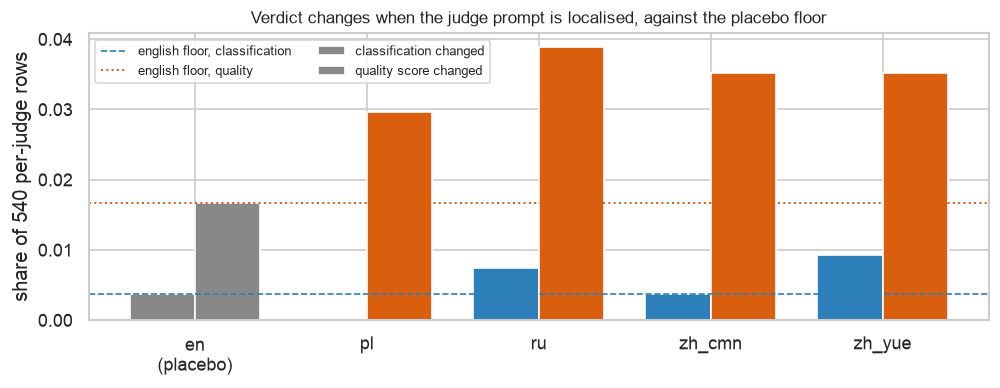

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
x = np.arange(len(LANGS))
width = 0.38
colours = ["#888" if lang == "en" else "#2c7fb8" for lang in LANGS]
quality_colours = ["#888" if lang == "en" else "#d95f0e" for lang in LANGS]
ax.bar(x - width / 2, flips["label_flip"], width, color=colours, label="classification changed")
ax.bar(x + width / 2, flips["quality_flip"], width, color=quality_colours,
       label="quality score changed")
ax.axhline(flips.loc["en", "label_flip"], color="#2c7fb8", ls="--", lw=1,
           label="english floor, classification")
ax.axhline(flips.loc["en", "quality_flip"], color="#d95f0e", ls=":", lw=1.2,
           label="english floor, quality")
ax.set_xticks(x, [f"{lang}\n(placebo)" if lang == "en" else lang for lang in LANGS])
ax.set_ylabel("share of 540 per-judge rows")
ax.set_title("Verdict changes when the judge prompt is localised, against the placebo floor",
             fontsize=10)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

The floor is doing real work here.

- **The English prompts match**, differing only in trailing whitespace on two lines out of 39. The English bars are a same-instrument re-run and measure nothing but judge nondeterminism, so the placebo holds.

- **Classification is unmoved.** Non-English label flips run from 0.0 to 0.9 percent against an English floor of 0.4 percent. Polish, on a fully localised prompt, changed no label at all, which is *below* the placebo. There is no signal to separate from noise on the classification side.

- **Quality scores move about twice the floor**, 3.0 to 3.9 percent against 1.7 percent. That is the one place localisation does something measurable, and it lands on the metric the exploration notebook already identifies as the judges' weak point. Section 3 asks whether the movement is an improvement.

One caveat worth stating plainly. With a single re-run per condition, the floor is itself estimated from 540 rows, so it is only known to roughly a percentage point. This section supports the statement "non-English sits at or near the floor". It does not support a fine ranking of the four languages against each other.

## 2. The headline finding under both instruments

The result to defend is the paired one from section 5 of the exploration notebook: on identical items, the model refuses answerable questions more often once they are translated. It is re-run here unchanged, once per instrument.

**How to read the tables below.** Each of the 60 answerable items exists in all five languages, so English and one other language can be compared item by item. `en_only` counts items that English refuses and the other language does not. `other_only` counts the reverse. Only those disagreements carry information, and if translation changed nothing the two columns would be roughly equal. `p` is an exact McNemar test on that split, and `p_holm` adjusts it for the fact that four languages are being tested at once, which is the column to read.

The question for this notebook is not whether the finding holds. It is whether the two instruments give the same answer.

In [ ]:
def mcnemar_exact(x, y):
    """
    Exact McNemar test on paired binary outcomes.

    Only discordant items carry information, so the test conditions on the
    discordant count and asks whether the split is even.
    """
    b = int((x & ~y).sum())
    c = int((~x & y).sum())
    n = b + c
    
    if n == 0:
        return b, c, float("nan")
    
    k = min(b, c)
    
    return b, c, min(1.0, 2 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n)


def holm(pvals):
    """Holm step-down adjustment over one family of four comparisons."""
    pvals = np.asarray(pvals, dtype=float)
    order = np.argsort(pvals)
    adjusted = np.empty(len(pvals))
    running = 0.0
    
    for rank, idx in enumerate(order):
        running = max(running, (len(pvals) - rank) * pvals[idx])
        adjusted[idx] = min(1.0, running)
    
    return adjusted


rows = []
for name, frame in consensus.items():
    answerable = frame[frame["answerable"]]
    wide = answerable.pivot(index="id", columns="language", values="refused").astype(bool)
    assert not wide.isna().any().any(), f"{name}: every item must appear in every language"
    raw = []
    
    for lang in OTHER:
        b, c, p = mcnemar_exact(wide["en"], wide[lang])
        raw.append(p)
        rows.append({"run": name, "language": lang, "n_items": len(wide),
                     "en_frr": wide["en"].mean(), "other_frr": wide[lang].mean(),
                     "en_only": b, "other_only": c, "p": p})
    
    for row, p_adj in zip(rows[-len(OTHER):], holm(raw)):
        row["p_holm"] = p_adj

paired = pd.DataFrame(rows)
for name in RUNS:
    sub = paired[paired["run"] == name]
    print(f"{name}: {sub['n_items'].iloc[0]} answerable items per language, "
          f"english false refusal {sub['en_frr'].iloc[0]:.3f}")
    print(sub[["language", "other_frr", "en_only", "other_only", "p", "p_holm"]]
          .round(4).to_string(index=False))
    print()

wide_paired = paired.pivot(index="language", columns="run", values="other_frr").loc[OTHER]
wide_paired["delta"] = wide_paired["target prompt"] - wide_paired["english prompt"]
print("false refusal rate, target prompt minus english prompt")
print(wide_paired.round(4).to_string())
print()
print(f"largest change in any language: {wide_paired['delta'].abs().max():.4f} "
      f"({round(wide_paired['delta'].abs().max() * 60)} items out of 60)")

english prompt: 60 answerable items per language, english false refusal 0.150
language  other_frr  en_only  other_only      p  p_holm
      pl     0.3500        2          14 0.0042  0.0125
      ru     0.2833        1           9 0.0215  0.0430
  zh_cmn     0.2833        2          10 0.0386  0.0430
  zh_yue     0.3500        1          13 0.0018  0.0073

target prompt: 60 answerable items per language, english false refusal 0.150
language  other_frr  en_only  other_only      p  p_holm
      pl     0.3500        2          14 0.0042  0.0137
      ru     0.3000        1          10 0.0117  0.0234
  zh_cmn     0.2833        2          10 0.0386  0.0386
  zh_yue     0.3333        1          12 0.0034  0.0137

false refusal rate, target prompt minus english prompt
run       english prompt  target prompt   delta
language                                       
pl                0.3500         0.3500  0.0000
ru                0.2833         0.3000  0.0167
zh_cmn            0.2833         0.2

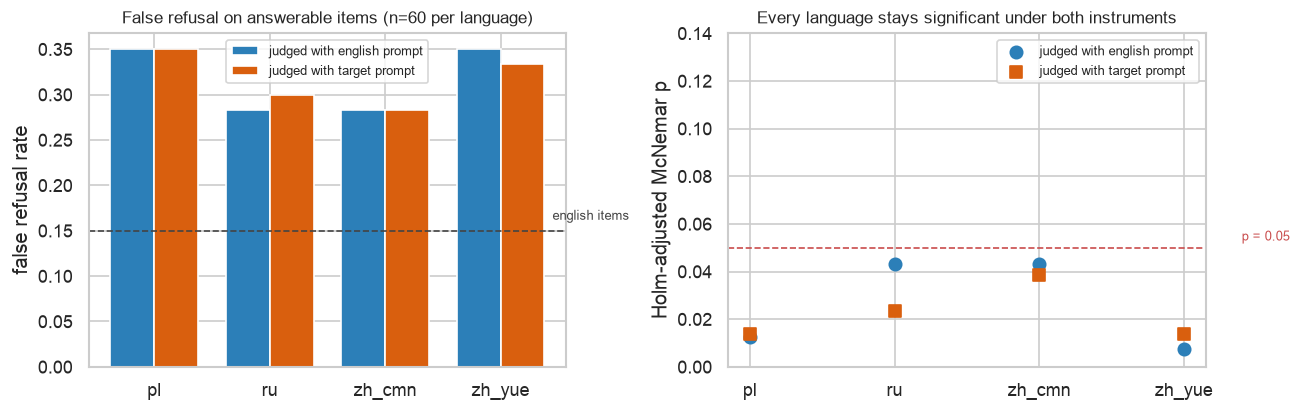

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

ax = axes[0]
x = np.arange(len(OTHER))
width = 0.38

for offset, (name, colour) in zip([-width / 2, width / 2],
                                  [("english prompt", "#2c7fb8"), ("target prompt", "#d95f0e")]):
    sub = paired[paired["run"] == name].set_index("language").loc[OTHER]
    ax.bar(x + offset, sub["other_frr"], width, color=colour, label=f"judged with {name}")

english_baseline = paired["en_frr"].iloc[0]
ax.axhline(english_baseline, color="#444", ls="--", lw=1)
ax.text(len(OTHER) - 0.55, english_baseline + 0.012, "english items", fontsize=8, color="#444")
ax.set_xticks(x, OTHER)
ax.set_ylabel("false refusal rate")
ax.set_title("False refusal on answerable items (n=60 per language)", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]

for name, colour, marker in [("english prompt", "#2c7fb8", "o"), ("target prompt", "#d95f0e", "s")]:
    sub = paired[paired["run"] == name].set_index("language").loc[OTHER]
    ax.scatter(np.arange(len(OTHER)), sub["p_holm"], s=55, color=colour, marker=marker,
               label=f"judged with {name}", zorder=3)

ax.axhline(0.05, color="#c94c4c", ls="--", lw=1)
ax.text(len(OTHER) - 0.6, 0.053, "p = 0.05", fontsize=8, color="#c94c4c")
ax.set_xticks(np.arange(len(OTHER)), OTHER)
ax.set_ylim(0, 0.14)
ax.set_ylabel("Holm-adjusted McNemar p")
ax.set_title("Every language stays significant under both instruments", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

The finding is untouched.

- **The rates barely move.** The largest change in any language is one item out of 60. Polish and Mandarin are identical to three decimal places, Russian gains an item and Cantonese loses one. English itself is unchanged at 0.150.

- **Every language still clears Holm correction.** The adjusted p values run 0.007 to 0.043 under the English prompt against 0.014 to 0.039 under the target prompt, and the disagreement counts stay one-sided in the same direction throughout. The ranking among the four shuffles slightly, with Polish and Cantonese now tied for the smallest adjusted p where Cantonese led alone before. That is what a one-item change does at this sample size, not a change of conclusion.

- **No language moves towards the English baseline.**

That last point is the one that matters. A judge that was harsher on text it was not instructed in would show up here as the non-English false refusal rates *falling* once each judge read its own language. They do not fall. The instrument is not manufacturing the gap.

## 3. Does localisation buy better judges?

Section 1 found that quality scoring is the one thing localisation moves. That fits the exploration notebook's first conclusion, which is that the three judges agree almost perfectly on refusal codes and only moderately on quality. If localising the prompt helps anywhere, this is where it should show.

**Two agreement measures, asking different things.** Cohen's kappa asks whether two judges assign the *same label*, beyond what chance would predict given how often each label is used. Spearman's rho asks whether two judges *rank* answers the same way on the 1 to 5 quality scale. Both run to 1.0 for perfect agreement. What matters below is not their level but whether localisation moves them, and whether it moves all three judge pairs the same way.

In [ ]:
overall = {name: frame[frame["scope"] == "overall"].set_index(["judge_a", "judge_b", "metric"])["value"]
           for name, frame in agreement.items()}
compare = pd.DataFrame(overall)
compare["delta"] = compare["target prompt"] - compare["english prompt"]
print("inter-judge agreement, overall scope")
print(compare.round(4).to_string())
print()

for metric, label in [("classification_cohen_kappa", "classification kappa"),
                      ("quality_spearman", "quality spearman")]:
    sub = compare.xs(metric, level="metric")
    print(f"{label}: {sub['delta'].min():+.3f} to {sub['delta'].max():+.3f} across judge pairs")

print()

# the refusal code vocabulary is the dominant fact about this run, so check the
# localised judges did not simply unlock the codes the model never appeared to use.
print("codes the consensus never assigns, over all 900 items")

for name, frame in consensus.items():
    unseen = sorted(REFUSAL_CODES - set(frame["model_predicted_type"].astype(str)))
    share = frame[~frame["answerable"]]["model_predicted_type"].eq(
        "REFUSE_INFO_MISSING_IN_CONTEXT").mean()
    print(f"  {name:16s} never emitted: {', '.join(unseen)}")
    print(f"  {'':16s} INFO_MISSING share of unanswerable predictions: {share:.3f}")

inter-judge agreement, overall scope


                                                                english prompt  target prompt   delta
judge_a          judge_b          metric                                                             
mistral-large-3  nemotron-3-super classification_pct_agreement          0.9900         0.9911  0.0011
                                  classification_cohen_kappa            0.9842         0.9860  0.0018
                                  quality_mean_abs_diff                 0.3333         0.2891 -0.0442
                                  quality_spearman                      0.6713         0.7025  0.0312
                 sonnet4_5        classification_pct_agreement          0.9944         0.9911 -0.0033
                                  classification_cohen_kappa            0.9912         0.9860 -0.0052
                                  quality_mean_abs_diff                 0.3005         0.2844 -0.0161
                                  quality_spearman                      0.6991   

Nothing improves and nothing degrades.

- **Classification kappa is flat**, moving by at most 0.005 in either direction across the three judge pairs, from a base of 0.984 to 0.993. There was no room to improve and none was taken.

- **Quality Spearman moves in both directions**, up for two pairs by 0.031 and 0.007 and down for the third by 0.070. A real improvement would move all three the same way. This is the same judge nondeterminism section 1 measured, redistributed rather than reduced.

- **The label collapse is a property of the model, not of the judge prompt.** `REFUSE_GRANULARITY_MISMATCH` and `REFUSE_OTHER` are still never emitted once in 900 items, and `REFUSE_INFO_MISSING_IN_CONTEXT` still absorbs the same 60 percent of predictions on unanswerable items, 0.607 against 0.605. This was worth ruling out. An English-instructed judge that simply failed to recognise non-English refusals of those two kinds would have produced exactly the collapse the exploration notebook reports, and it did not.

So localised judge prompts are not a quality upgrade. They cost an extra translated asset that has to be kept in sync with the rubric and they buy no measurable agreement.

## 4. Everything else, for completeness

Sections 2 and 3 cover the claims that matter. This is the exhaustive sweep over every metric, language and judge, so that "nothing changed" is a checked statement rather than a selective one.

consensus metrics, target prompt minus english prompt
          answer_accuracy  refusal_accuracy  false_refusal_rate  missed_refusal_rate  calibrated_refusal_score
language                                                                                                      
en                 0.0167           -0.0083              0.0000               0.0083                    0.0042
pl                 0.0000            0.0000              0.0000               0.0000                    0.0000
ru                 0.0167            0.0000              0.0167               0.0000                    0.0083
zh_cmn             0.0000            0.0000              0.0000               0.0000                    0.0000
zh_yue             0.0167            0.0000             -0.0167               0.0000                    0.0083

largest absolute change anywhere, over every judge, language and metric
answer_accuracy             0.0500
refusal_accuracy            0.0083
false_refusal_rate        

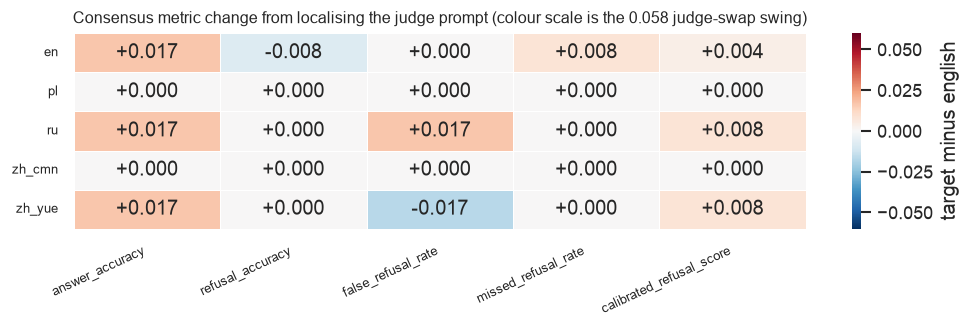

In [7]:
METRICS = ["answer_accuracy", "refusal_accuracy", "false_refusal_rate",
           "missed_refusal_rate", "calibrated_refusal_score"]

lang_delta = (metrics_lang["target prompt"].set_index(["judge_id", "language"])[METRICS]
              - metrics_lang["english prompt"].set_index(["judge_id", "language"])[METRICS])
consensus_delta = lang_delta.xs("consensus", level="judge_id").loc[LANGS]

print("consensus metrics, target prompt minus english prompt")
print(consensus_delta.round(4).to_string())
print()
print("largest absolute change anywhere, over every judge, language and metric")
print(lang_delta.abs().max().round(4).to_string())
print()

label_agreement = (consensus["english prompt"].set_index(key)["model_predicted_type"]
                   == consensus["target prompt"].set_index(key)["model_predicted_type"]).mean()
print(f"consensus classification labels identical across runs: {label_agreement:.4f} "
      f"({int(round((1 - label_agreement) * 900))} of 900 items differ)")

fig, ax = plt.subplots(figsize=(8.5, 2.9))
sns.heatmap(consensus_delta, annot=True, fmt="+.3f", cmap="RdBu_r", center=0,
            vmin=-0.06, vmax=0.06, ax=ax, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "target minus english"})
ax.set_title("Consensus metric change from localising the judge prompt "
             "(colour scale is the 0.058 judge-swap swing)", fontsize=9.5)
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

**The colour scale is set deliberately.** Section 2 of the exploration notebook found that simply choosing which of the three judges to trust moves the calibrated score by up to 0.058. The heatmap is scaled to that swing, so a cell would have to be strongly coloured before the change from localising the prompt rivalled the change from swapping judges. Every cell is close to white.

The largest consensus change on any language and metric is 0.017. The largest change for any single judge is 0.050 on `answer_accuracy`, which is the metric gated on the quality score and therefore exactly the one section 1 predicted would move most.

Consensus classification labels are identical on 896 of the 900 items.

## 5. Conclusions

### On the question asked

1. **Localising the judge prompt does not change what the pilot concludes.** Consensus classification labels are identical on 896 of 900 items, no consensus metric on any language moves by more than 0.017, and the largest change for any single judge is 0.050 on the one metric gated on the quality score.

2. **The cross-language false refusal finding survives intact.** Under target-language judge prompts the rates move by at most one item in 60, English is unchanged at 0.150, all four languages still clear Holm correction, and the disagreements stay one-sided in the same direction. Crucially, no language moves towards the English baseline, which is what a judge biased against text it was not instructed in would have produced. The finding is not an artefact of the measuring instrument.

3. **Classification sits at the placebo floor. Quality sits slightly above it.** Because the English localised prompt is the canonical prompt up to trailing whitespace, the English slice measures pure judge nondeterminism, and it comes to 0.4 percent of labels and 1.7 percent of quality scores changing on a same-prompt re-run. Non-English label flips run 0.0 to 0.9 percent, which is the floor. Quality flips run 3.0 to 3.9 percent, about twice it.

4. **Localisation is not a judge-quality upgrade.** Inter-judge classification kappa moves by at most 0.005, and quality Spearman moves up for two judge pairs and down for the third, which is noise rather than improvement. The refusal-code collapse is unchanged under both instruments, so it is a property of the evaluated model and not an artefact of judging non-English responses with English instructions.

### What follows (by Claude)

5. **Keep `english` as the canonical judge prompt.** It is the cheaper configuration, it needs no translated judge segments kept in sync with the rubric, and the localised run shows it costs nothing in accuracy or agreement. Keep `--judge-prompt-language target` as a robustness check to re-run when the rubric or the language set changes, not as the default.

6. **This closes the measurement-side threat only.** [`pilot_v2_leakage_subsets.ipynb`](pilot_v2_leakage_subsets.ipynb) closes the input-side threat, finding that the cross-language gap grows rather than shrinks on cleaner items, though it pins down the direction of that effect rather than its size. Between the two notebooks, both artefact explanations raised against the cross-language false refusal result have now been tested and neither survives. The outstanding check is the one neither notebook can do, which is review of the translations by a speaker of each language.

7. **The remaining judge problem is unchanged and is not about language.** Quality scoring is where the judges disagree, at Spearman 0.62 to 0.71 across the two runs, and localising the prompt neither helps nor hurts. Recommendation 15 of the exploration notebook stands: a tighter quality rubric buys more than any change to the prompt language.